# Objetivo do notebook

Iniciar um processo de investigação passo a passo do dataset PCOS Dataset

## Etapa 1 (Reconhecimento)

**Pergunta**: "O que temos aqui?"

Antes de qualquer limpeza, é preciso entender a estrutura básica do dataset.

### 1.1 Carregar o dataset e visualizar o shape

Shape: quantidade de linhas (amostras) e colunas (variáveis)

In [146]:
import pandas as pd
import numpy as np

arquivo = "../datasets/PCOS_data_without_infertility.xlsx"
df = pd.read_excel(arquivo, sheet_name="Full_new")

print(f"Shape do dataset: { df.shape }")
print(f"Linhas do dataset: { df.shape[0] }")
print(f"Colunas do dataset: { df.shape[1] }")

Shape do dataset: (541, 45)
Linhas do dataset: 541
Colunas do dataset: 45


### 1.2 Ver as primeiras linhas com .head()

Que tipo de informação tem, valores típicos, etc

In [147]:
df.head(10) #mostra as 10 primeiras linhas do dataset

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,1,1,0,28,44.6,152.0,19.300000,15,78,22,...,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,2,2,0,36,65.0,161.5,24.921163,15,74,20,...,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,3,3,1,33,68.8,165.0,25.270891,11,72,18,...,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN
3,4,4,0,37,65.0,148.0,29.674945,13,72,20,...,0.0,0,120,70,2,2,15.0,14.0,7.5,NaN
4,5,5,0,25,52.0,161.0,20.060954,11,72,18,...,0.0,0,120,80,3,4,16.0,14.0,7.0,NaN
5,6,6,0,36,74.1,165.0,27.217631,15,78,28,...,0.0,0,110,70,9,6,16.0,20.0,8.0,NaN
6,7,7,0,34,64.0,156.0,26.298488,11,72,18,...,0.0,0,120,80,6,6,15.0,16.0,6.8,NaN
7,8,8,0,33,58.5,159.0,23.139907,13,72,20,...,0.0,0,120,80,7,6,15.0,18.0,7.1,NaN
8,9,9,0,32,40.0,158.0,16.023073,11,72,18,...,0.0,0,120,80,5,7,17.0,17.0,4.2,NaN
9,10,10,0,36,52.0,150.0,23.111111,15,80,20,...,0.0,0,110,80,1,1,14.0,17.0,2.5,NaN


#### O que olhar no .head()
- os valores fazem sentido?
- tem colunas que parecem ser ids?
- tem colunas vazias ou com muito NaN?
- nomes de colunas legíveis ou com caracteres estranhos?

*O que eu percebi:* 
- coluna com Sl. No e Patient File No. que parecem ser índices
- tem uma coluna Unnamed: 44 

### 1.3 Listar todos os nomes das colunas

Muitas vezes só o .head() não mostra todas se o dataset tem bastante colunas. Com isso vale listar os nomes completos com o .columns

In [148]:
print("Lista completa com os nomes das colunas: ")
for i, col in enumerate(df.columns):
    print(f"{i+1} - {repr(col)}") # o repr mostra espaçoes e caracteres especiais, como \n, \t, etc.

Lista completa com os nomes das colunas: 
1 - 'Sl. No'
2 - 'Patient File No.'
3 - 'PCOS (Y/N)'
4 - ' Age (yrs)'
5 - 'Weight (Kg)'
6 - 'Height(Cm) '
7 - 'BMI'
8 - 'Blood Group'
9 - 'Pulse rate(bpm) '
10 - 'RR (breaths/min)'
11 - 'Hb(g/dl)'
12 - 'Cycle(R/I)'
13 - 'Cycle length(days)'
14 - 'Marraige Status (Yrs)'
15 - 'Pregnant(Y/N)'
16 - 'No. of aborptions'
17 - '  I   beta-HCG(mIU/mL)'
18 - 'II    beta-HCG(mIU/mL)'
19 - 'FSH(mIU/mL)'
20 - 'LH(mIU/mL)'
21 - 'FSH/LH'
22 - 'Hip(inch)'
23 - 'Waist(inch)'
24 - 'Waist:Hip Ratio'
25 - 'TSH (mIU/L)'
26 - 'AMH(ng/mL)'
27 - 'PRL(ng/mL)'
28 - 'Vit D3 (ng/mL)'
29 - 'PRG(ng/mL)'
30 - 'RBS(mg/dl)'
31 - 'Weight gain(Y/N)'
32 - 'hair growth(Y/N)'
33 - 'Skin darkening (Y/N)'
34 - 'Hair loss(Y/N)'
35 - 'Pimples(Y/N)'
36 - 'Fast food (Y/N)'
37 - 'Reg.Exercise(Y/N)'
38 - 'BP _Systolic (mmHg)'
39 - 'BP _Diastolic (mmHg)'
40 - 'Follicle No. (L)'
41 - 'Follicle No. (R)'
42 - 'Avg. F size (L) (mm)'
43 - 'Avg. F size (R) (mm)'
44 - 'Endometrium (mm)'
45 - 'Unna

#### O que olhar no resultado dos nomes das colunas
- nomes com espaços no começo/fim?
- erros de digitação?
- colunas unnamed?
- nomes muito parecidos que podem confundir?

*O que eu percebi:* 
- espaços extras em vários nomes, como na coluna 4, 6, 9, 17, 18 (dá pra ser corrigido com strip)
- erros nos nomes, como marraige (acho que deveria ser marriage), aborptions (acho que deveria ser abortions)
- coluna com unnamed: Unnamed 44

## Etapa 2 (Entender os tipos de dados)

**Pergunta**: "Cada coluna significa o que? (número, texto, data)"

O tipo (dtype) de uma coluna diz como o pandas a interpreta, se estiver errado, os cálculos vão quebrar.

### 2.1 Ver informação completa com .info()

info: mostra nome de coluna, quantos valores não nulos, o tipo

In [149]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 45 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sl. No                  541 non-null    int64  
 1   Patient File No.        541 non-null    int64  
 2   PCOS (Y/N)              541 non-null    int64  
 3    Age (yrs)              541 non-null    int64  
 4   Weight (Kg)             541 non-null    float64
 5   Height(Cm)              541 non-null    float64
 6   BMI                     541 non-null    float64
 7   Blood Group             541 non-null    int64  
 8   Pulse rate(bpm)         541 non-null    int64  
 9   RR (breaths/min)        541 non-null    int64  
 10  Hb(g/dl)                541 non-null    float64
 11  Cycle(R/I)              541 non-null    int64  
 12  Cycle length(days)      541 non-null    int64  
 13  Marraige Status (Yrs)   540 non-null    float64
 14  Pregnant(Y/N)           541 non-null    in

#### O que olhar no resultado do info()
- coluna com object?
- non-null count?
- colunas quase vazias?

*O que eu percebi:* 
- colunas 17 e 25 como object - preciso investigar
- coluna unnamed 44 só com 2 valores, candidata a ser descartada
- coluna 13 e 35 com 1 valor nulo - investigar

### 2.2 Porque as colunas mapeadas acima são object?

tentar converter de forma forçada. Se converter pra numérico com o pd.to_numeric, os valores válidos viram número e os inválidos viram NaN

In [150]:
colunas_suspeitas = ["II    beta-HCG(mIU/mL)", "AMH(ng/mL)"]

for col in colunas_suspeitas:
    print(f"\nInvestigando a coluna: {col}")
    print("-" * 60)
    
    # converter forçadamente para numérico, substituindo valores não numéricos por NaN
    convertido = pd.to_numeric(df[col], errors='coerce')
    
    # contar linhas que falharam na conversão (viraram NaN mas o original não era NaN)
    mascara_problema = convertido.isna() & df[col].notna()
    valores_problematicos = df.loc[mascara_problema, col].unique()
    
    print(f"Valores que não são numéricos: {valores_problematicos}")
    print(f"Quantidade de linhas afetadas: {mascara_problema.sum()}")


Investigando a coluna: II    beta-HCG(mIU/mL)
------------------------------------------------------------
Valores que não são numéricos: ['1.99.']
Quantidade de linhas afetadas: 1

Investigando a coluna: AMH(ng/mL)
------------------------------------------------------------
Valores que não são numéricos: ['a']
Quantidade de linhas afetadas: 1


*O que eu percebi:* 
- coluna II    beta-HCG(mIU/mL) -> valor ['1.99.'] -> dois pontos, erro de digitação talvez?
- coluna AMH(ng/mL) -> valor ['a'] -> letra no lugar de um número, erro de digitação?

### 2.3 Quantificar valores ausentes

contar todos os nulos

In [151]:
nulos = df.isna().sum()

# mostrar colunas que tem algum valor nulo
print("Colunas com valores nulos:")
print(nulos[nulos > 0].sort_values(ascending=False) )

# percentual de valores nulos por coluna
print("\nPercentual de valores nulos por coluna:")
percentual_nulos = (nulos[nulos > 0] / len(df) * 100).round(1)
print(percentual_nulos.sort_values(ascending=False))


Colunas com valores nulos:
Unnamed: 44              539
Marraige Status (Yrs)      1
Fast food (Y/N)            1
dtype: int64

Percentual de valores nulos por coluna:
Unnamed: 44              99.6
Marraige Status (Yrs)     0.2
Fast food (Y/N)           0.2
dtype: float64


*O que eu percebi:* 
- coluna Unnamed 44 com 99.6% vazia -> remover
- coluna Marraige Status (Yrs) com 1 nulo -> imputar?
- coluna Fast food (Y/N) com 1 nulo -> imputar?

> **Regra prática (peguei de vídeos do youtube e IA):**
> - Coluna com > 50% de nulos → geralmente removemos
> - Nulos < 5% → imputar (mediana/moda/média)
> - Entre 5-50% → depende do contexto (pode imputar ou remover)

## Etapa 3 (Estatísticas Descritivas)

**Pergunta**: "Os valores das features fazem sentido?"

O describe() mostra min, máx, média, quartis... ajuda a detectar outliers

In [152]:
df.describe().T # o .T transpõe a tabela, mostrando as estatísticas descritivas por coluna em linhas. Fica mais legível.

,count,mean,std,min,25%,50%,75%,max
Sl. No,541.0,271.000000,156.317519,1.000000,136.000000,271.000000,406.000000,541.000000
Patient File No.,541.0,271.000000,156.317519,1.000000,136.000000,271.000000,406.000000,541.000000
PCOS (Y/N),541.0,0.327172,0.469615,0.000000,0.000000,0.000000,1.000000,1.000000
Age (yrs),541.0,31.430684,5.411006,20.000000,28.000000,31.000000,35.000000,48.000000
Weight (Kg),541.0,59.637153,11.028287,31.000000,52.000000,59.000000,65.000000,108.000000
Height(Cm),541.0,156.484835,6.033545,137.000000,152.000000,156.000000,160.000000,180.000000
BMI,541.0,24.311285,4.056399,12.417882,21.641274,24.238227,26.634958,38.900000
Blood Group,541.0,13.802218,1.840812,11.000000,13.000000,14.000000,15.000000,18.000000
Pulse rate(bpm),541.0,73.247689,4.430285,13.000000,72.000000,72.000000,74.000000,82.000000
RR (breaths/min),541.0,19.243993,1.688629,16.000000,18.000000,18.000000,20.000000,28.000000


#### O que procurar no .describe()
- min/max absurdos?
- média muito diferente da mediana?
- std (desvio padrão) gigante?
- valores impossíveis?

*O que eu percebi:* 
- BMI -> valores extremos (usei IA para me explicar)
- FSH/LH -> valores próximos de zero

> O ideal é verificar esses outliers com especialistas médicos

## Etapa 4 (Entender o target - variável alvo)

**Pergunta**: "O que estou tentando prever? As classes estão balanceadas?"

O target é a variável  que o modelo vai prever. Necessário verificar se está OK

Distribuição da variável alvo (target):
PCOS (Y/N)
0    364
1    177
Name: count, dtype: int64

Percentual da variável alvo (target):
PCOS (Y/N)
0    67.3
1    32.7
Name: proportion, dtype: float64


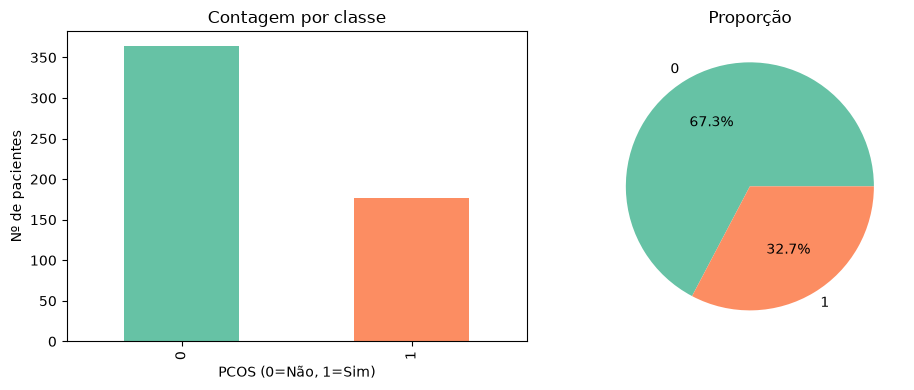

In [153]:
target = "PCOS (Y/N)"

# contagem absoluta de cada classe
print("Distribuição da variável alvo (target):")
print(df[target].value_counts())

# percentual de cada classe
print("\nPercentual da variável alvo (target):")
print((df[target].value_counts(normalize=True) * 100).round(1))

# gerando um gráfico visual
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
df[target].value_counts().plot(kind="bar", ax=ax[0], color=["#66c2a5", "#fc8d62"])
ax[0].set_title("Contagem por classe")
ax[0].set_xlabel("PCOS (0=Não, 1=Sim)")
ax[0].set_ylabel("Nº de pacientes")

df[target].value_counts(normalize=True).plot(kind="pie", ax=ax[1], autopct="%1.1f%%",
                                               colors=["#66c2a5", "#fc8d62"])
ax[1].set_title("Proporção")
ax[1].set_ylabel("")
plt.tight_layout()
plt.show()

*O que eu percebi:* 
- Classe 0 -> ~67%
- Classe 1 -> ~33%

Um pouco desbalanceado

**Implicações práticas (utilizei IA pra me ajudar):**

1. **NÃO confiar só na Acurácia.** Um modelo "burro" que chuta sempre "0" teria 67%
   de acerto. Precisamos de métricas melhores: **Recall, F1, Matriz de Confusão**.

2. **Usar `stratify=y` no train_test_split.** Garante que treino e teste tenham
   a mesma proporção 67/33.

3. **Em diagnóstico médico, Recall (sensibilidade) é CRÍTICO.** Falso negativo
   (dizer que tem PCOS mas o modelo diz que não) é GRAVE — diagnóstico perdido.

## Etapa 5 (Buscar redundâncias e correlações)

**Pergunta**: "Temos features duplicadas ou que medem a mesma coisa?"

Features muito correlacionadas (> 0.9) podem causar problemas (multicolinearidade).

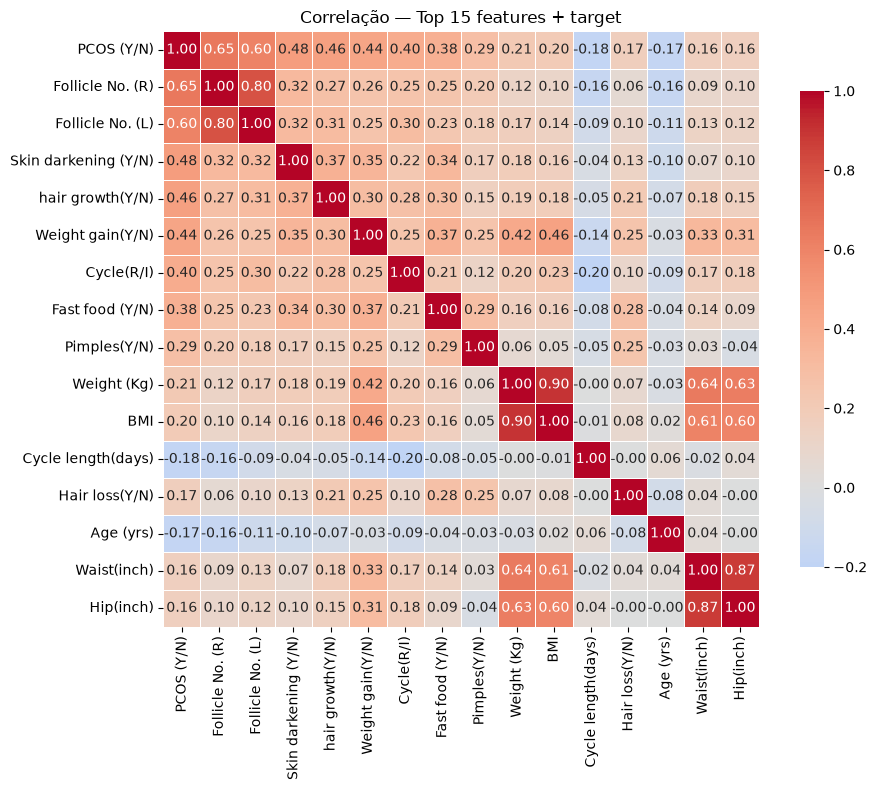

In [154]:
# matriz de correlação (apenas features numéricas)
numericas = df.select_dtypes(include=[np.number])
corr = numericas.corr()

# heatmap (só das features mais relevantes, senão fica ilegível)
# pegando as top 15 features mais correlacionadas com o target
if target in corr.columns:
    top_features = corr[target].abs().sort_values(ascending=False).head(16).index
    corr_top = numericas[top_features].corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_top, annot=True, fmt=".2f", cmap="coolwarm", center=0,
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title("Correlação — Top 15 features + target")
    plt.tight_layout()
    plt.show()

**Como ler a matriz de correlação:**

- **Diagonal = 1.0:** uma variável sempre tem correlação perfeita consigo mesma
- **Valores próximos de +1:** muito correlacionadas (uma sobe, outra sobe)
- **Valores próximos de -1:** correlação negativa (uma sobe, outra desce)
- **Próximo de 0:** sem correlação linear

#### O que olhar no resultado de correlação
- procurar pares com correlação > 0.9 (exceto diagonal)
- quando encontrar, considerar remover uma das duas (normalmente o analista decide)
- verificar quais features tem maior correlação com o TARGET

*O que eu percebi:* 
- features que podem estar correlacionadas:
  - Weight e BMI -> BMI é calculado a partir do peso
  - Follicule No. (L) e Follicule No. (R) -> podem ter comportamento similar

## Etapa 6 (Visualizar Distribuições)

**Pergunta**: "Como os valores se distribuem? Tem outliers?"

Histogramas e boxplots mostram a "forma" dos dados

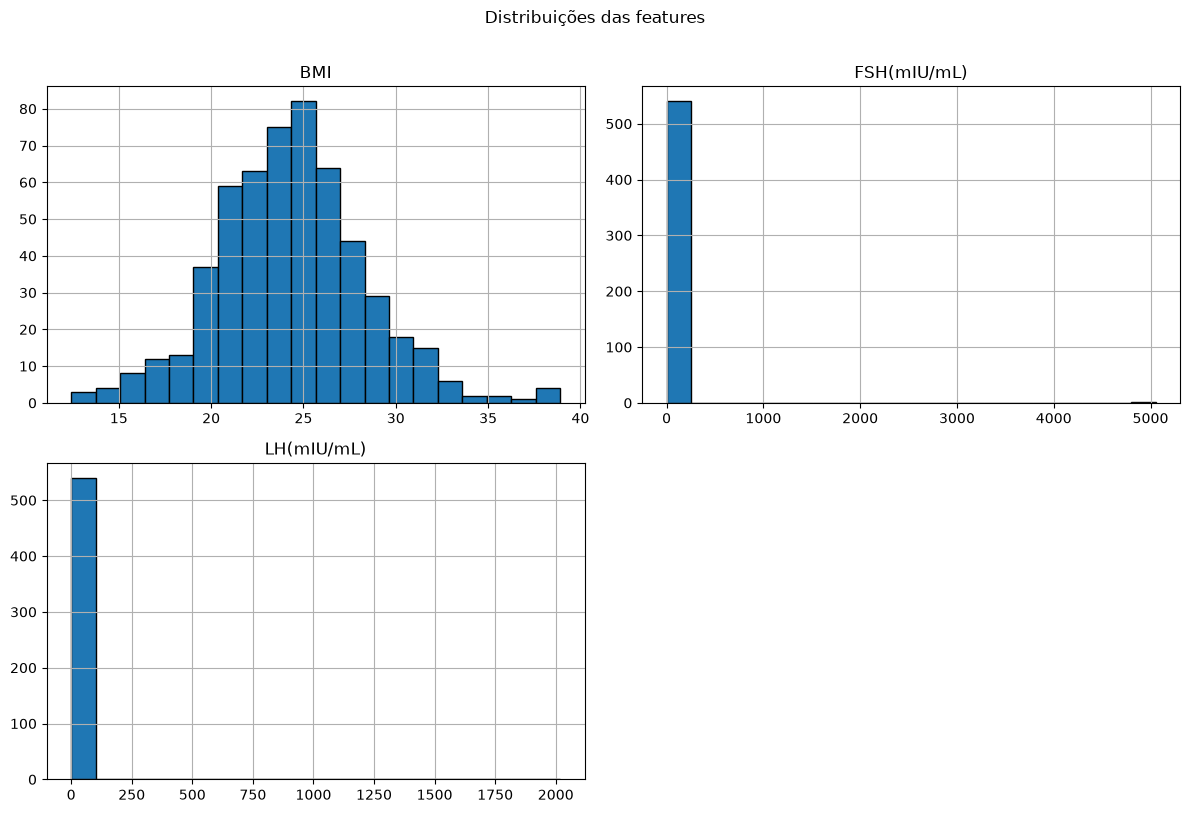

In [155]:
# escolhe algumas features contínuas interessantes
features_vis = ["Age (yrs)", "BMI", "FSH(mIU/mL)", "LH(mIU/mL)"]
# remove espaços dos nomes se já tiver limpado
features_vis = [c.strip() if c.strip() in df.columns else c for c in features_vis]
features_vis = [c for c in features_vis if c in df.columns]

# histogramas
df[features_vis].hist(bins=20, figsize=(12, 8), edgecolor="black")
plt.suptitle("Distribuições das features", y=1.01)
plt.tight_layout()
plt.show()

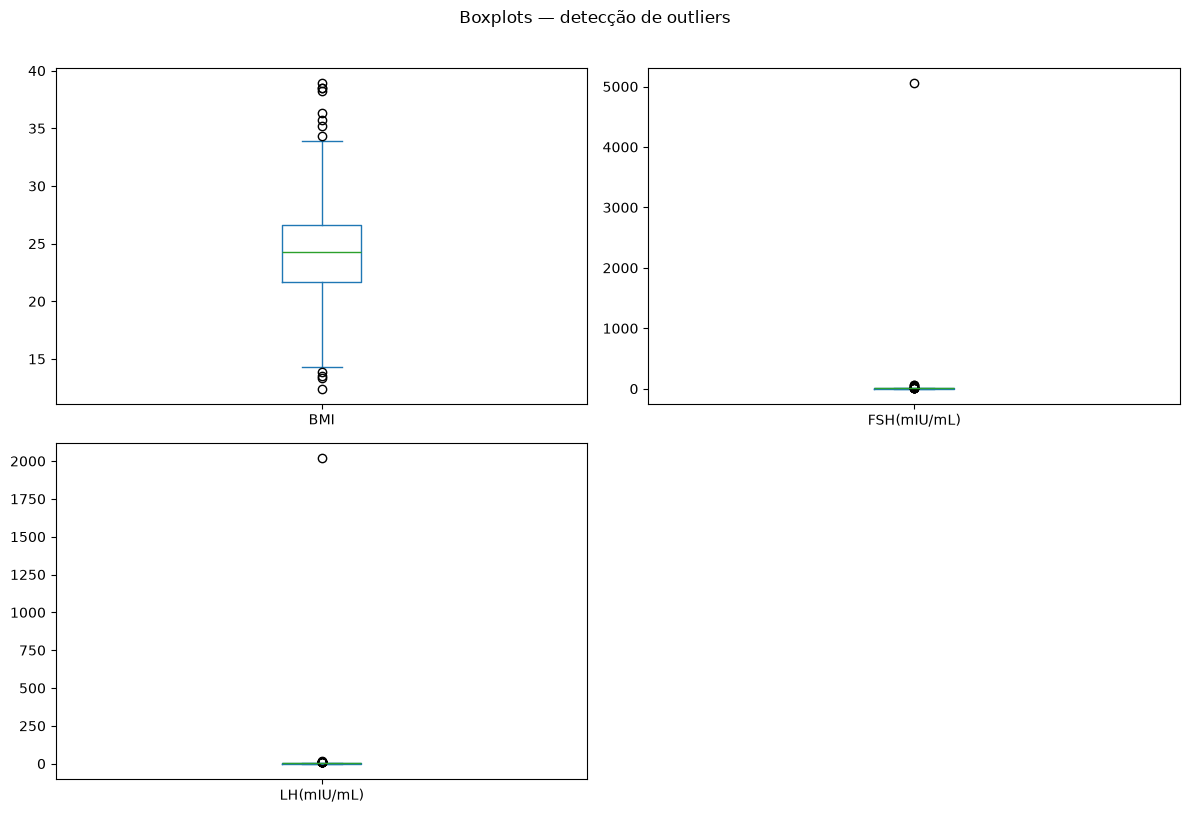

In [156]:
# boxplots (detectam outliers — pontos além dos "bigodes")
df[features_vis].plot(kind="box", subplots=True, layout=(2, 2), figsize=(12, 8))
plt.suptitle("Boxplots — detecção de outliers", y=1.01)
plt.tight_layout()
plt.show()

**Como interpretar:**

**Histograma:**
- Forma: simétrica? Assimétrica (skewed)? Bimodal (duas "montanhas")?
- Valores extremos isolados?

**Boxplot:**
- A "caixa" = 50% dos dados centrais (Q1 a Q3)
- Linha no meio = mediana
- "Bigodes" = até 1.5× IQR (intervalo interquartil)
- **Pontos além dos bigodes = outliers**

**Achados típicos:**

- **BMI:** outliers nos extremos (pacientes muito abaixo ou muito acima do peso normal)
- **Hormônios (FSH, LH, AMH):** distribuição assimétrica, outliers altos comuns
  (alguns valores muito elevados caracterizam PCOS)

> **NÃO remover outliers automaticamente em dados médicos!** Um FSH de 50 pode ser
> um caso real e extremo de PCOS. Consulte especialistas antes de descartar.


## Etapa 7 (Comparar grupos PCOS e não PCOS)

**Pergunta**: "Quais features diferenciam os dois grupos?"

Pacientes com PCOS tem valores diferentes de quem não tem?

C:\Users\fabar\AppData\Local\Temp\ipykernel_21544\1798935299.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target, y=feat, data=df, ax=axes[i], palette="Set2")
C:\Users\fabar\AppData\Local\Temp\ipykernel_21544\1798935299.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target, y=feat, data=df, ax=axes[i], palette="Set2")
C:\Users\fabar\AppData\Local\Temp\ipykernel_21544\1798935299.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target, y=feat, data=df, ax=axes[i], palette="Set2")
C:\Users\fabar\AppData\Local\Temp\ipyker

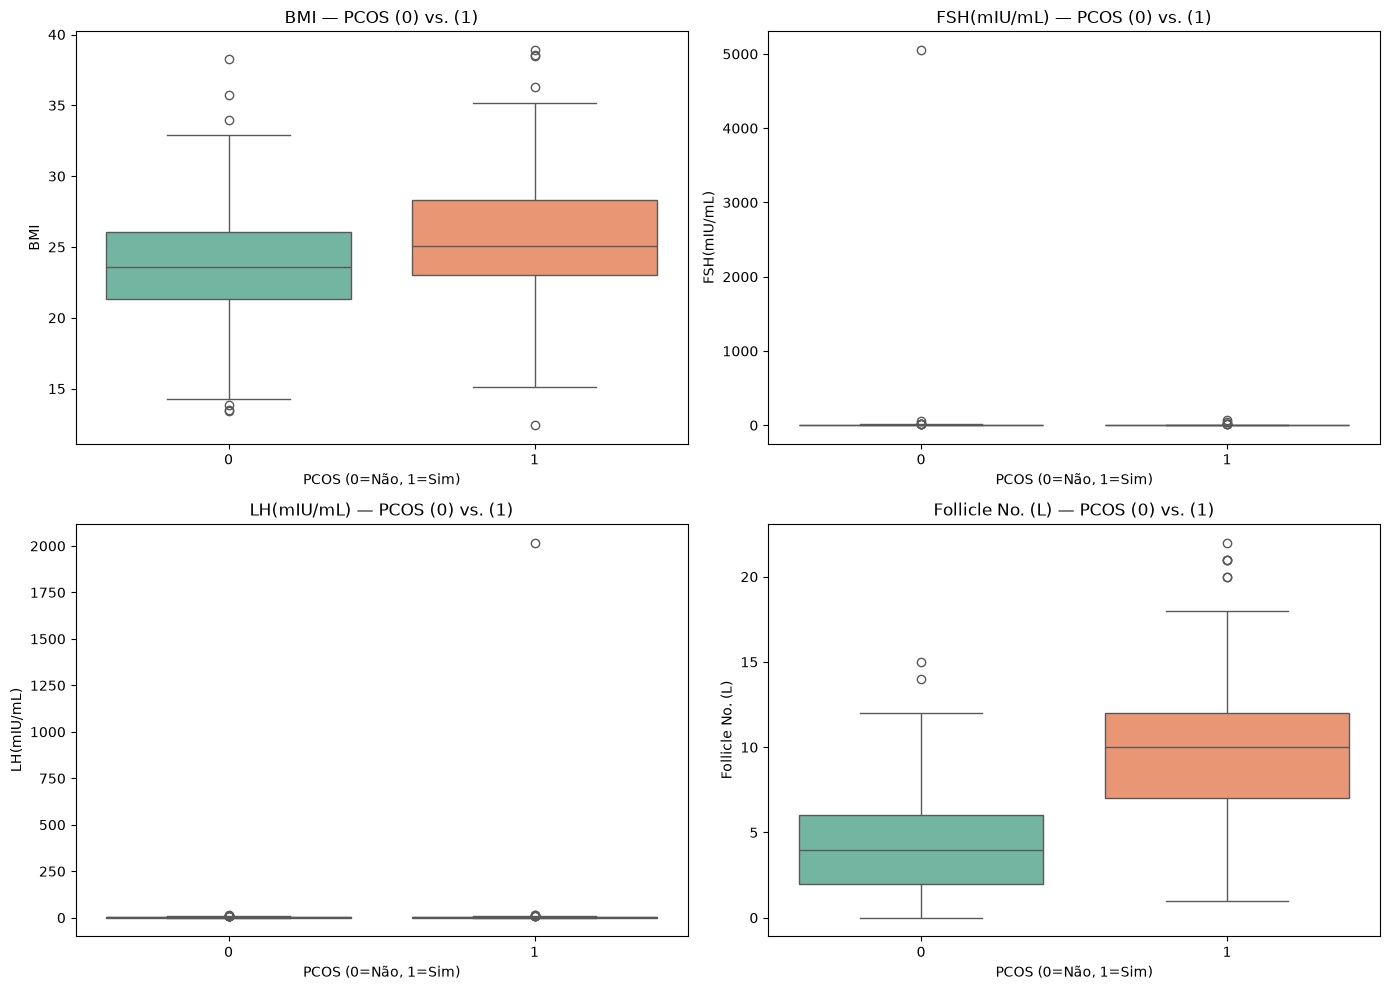

In [157]:
# boxplot comparativo: feature por classe
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

features_comparar = ["BMI", "FSH(mIU/mL)", "LH(mIU/mL)", "Follicle No. (L)"]
features_comparar = [c.strip() if c.strip() in df.columns else c for c in features_comparar]
features_comparar = [c for c in features_comparar if c in df.columns][:4]

for i, feat in enumerate(features_comparar):
    sns.boxplot(x=target, y=feat, data=df, ax=axes[i], palette="Set2")
    axes[i].set_title(f"{feat} — PCOS (0) vs. (1)")
    axes[i].set_xlabel("PCOS (0=Não, 1=Sim)")

plt.tight_layout()
plt.show()

#### O que olhar no resultado (interpretação clínica)
- FSH/LH elevado: razão LH/FSH costuma estar alterada em PCOS
- Mais folículos: número de folículos nos ovários tende a ser maior
- BMI maior: SOP está frequentemente associada a sobrepeso/obesidade
- Sintomas (hirsutismo, acne): mais comuns no grupo PCOS=1

> Essa análise ajuda a validar se o dataset "faz sentido" clinicamente e indica quais
> features vão ser importantes para o modelo.

## Etapa 8: Checklist Final — Resumo das Decisões

**Pergunta:** "O que fazer com cada problema encontrado?"

Consolidando tudo que descobrimos e montar o plano de ação.

### 📋 Plano de Pré-Processamento (decisões baseadas na investigação)

| # | Problema Encontrado | Evidência | Solução |
|---|---|---|---|
| 1 | Nomes com espaços extras | `repr()` mostrou `' Age (yrs)'` | `df.columns.str.strip()` |
| 2 | Erros de digitação nos nomes | `Marraige`, `aborptions` | Renomear (opcional) ou manter |
| 3 | `II beta-HCG` é texto | Valor `'1.99.'` encontrado | `pd.to_numeric(errors='coerce')` |
| 4 | `AMH` é texto | Valor `'a'` encontrado | `pd.to_numeric(errors='coerce')` |
| 5 | `Unnamed: 44` 99.6% vazia | `.info()` mostrou 2/541 | `df.drop()` |
| 6 | `Sl. No` e `Patient File No.` são IDs | `.head()` mostrou sequência | `df.drop()` |
| 7 | Nulos em `Marraige Status` (1) | `.isna().sum()` | Imputar com mediana |
| 8 | Nulos em `Fast food` (1) | `.isna().sum()` | Imputar com mediana |
| 9 | Nulos gerados pela coerção (etapa 3) | Conversão de `'1.99.'` e `'a'` | Imputar com mediana |
| 10 | Target desbalanceado (67/33) | `.value_counts()` | `stratify=y` no split + métricas certas |
| 11 | Outliers em hormônios/BMI | Boxplots mostraram pontos extremos | **NÃO remover** (podem ser casos reais) |
| 12 | Features em escalas diferentes | `.describe()` mostrou std variado | `StandardScaler` no pipeline |

**🎯 Ordem de execução:**
1. Limpar nomes (strip)
2. Remover colunas (IDs, Unnamed)
3. Converter tipos (to_numeric com coerce)
4. Tratar nulos (imputar mediana)
5. (Na modelagem) Escalar features no pipeline
6. (Na modelagem) Split com stratify
7. (Na modelagem) Treinar e avaliar com Recall/F1